In [1]:
# HealthGuard AI - Stroke EDA
# Author: HealthGuard AI Team
# Date: 2026
# Purpose: Exploratory Data Analysis of Stroke Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

print("=" * 50)
print("   HealthGuard AI - Stroke EDA")
print("=" * 50)
print("Libraries Loaded Successfully!")

   HealthGuard AI - Stroke EDA
Libraries Loaded Successfully!


In [2]:
# Load Stroke Dataset
# Source: Kaggle
# Records: 5110 patients, 12 columns

df = pd.read_csv("E:/HealthGuard_AI/data/raw/stroke.csv")

print("Dataset Loaded Successfully!")
print("=" * 50)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("=" * 50)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Loaded Successfully!
Total Rows: 5110
Total Columns: 12

Column Names:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

First 5 Rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# Basic Dataset Information

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
# Basic Dataset Information

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
# Check Missing Values

print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

print("Missing Values:")
print(df.isnull().sum())

total_missing = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")
print(f"BMI Missing: {df['bmi'].isnull().sum()} rows")
print(f"BMI Missing %: {df['bmi'].isnull().mean()*100:.1f}%")

MISSING VALUES CHECK
Missing Values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Total Missing Values: 201
BMI Missing: 201 rows
BMI Missing %: 3.9%


In [6]:
# Check Duplicate Rows

print("=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates Removed!")
    print(f"New Shape: {df.shape}")
else:
    print("No Duplicates Found!")

DUPLICATE CHECK
Total Duplicate Rows: 0
No Duplicates Found!


TARGET DISTRIBUTION
Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

No Stroke: 95.1%
Stroke: 4.9%



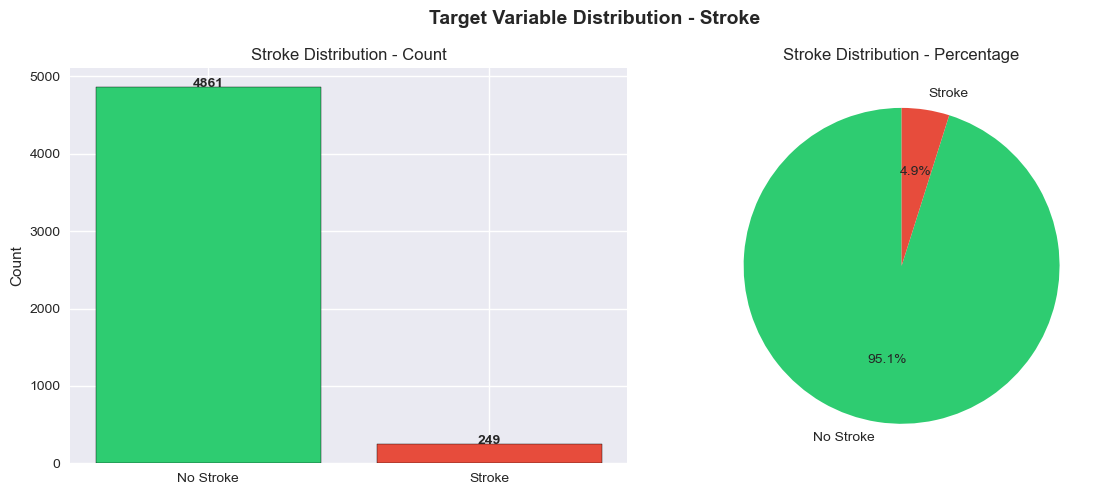

In [7]:
# Target Variable Distribution
# Note: Very imbalanced dataset!

print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)

print("Stroke Distribution:")
print(df['stroke'].value_counts())

percentage = df['stroke'].value_counts(normalize=True) * 100
print(f"\nNo Stroke: {percentage[0]:.1f}%")
print(f"Stroke: {percentage[1]:.1f}%")
print("\nWARNING: Dataset is highly imbalanced!")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Stroke', 'Stroke'],
            df['stroke'].value_counts(),
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Stroke Distribution - Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['stroke'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(df['stroke'].value_counts(),
            labels=['No Stroke', 'Stroke'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Stroke Distribution - Percentage')

plt.suptitle('Target Variable Distribution - Stroke',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Categorical Columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


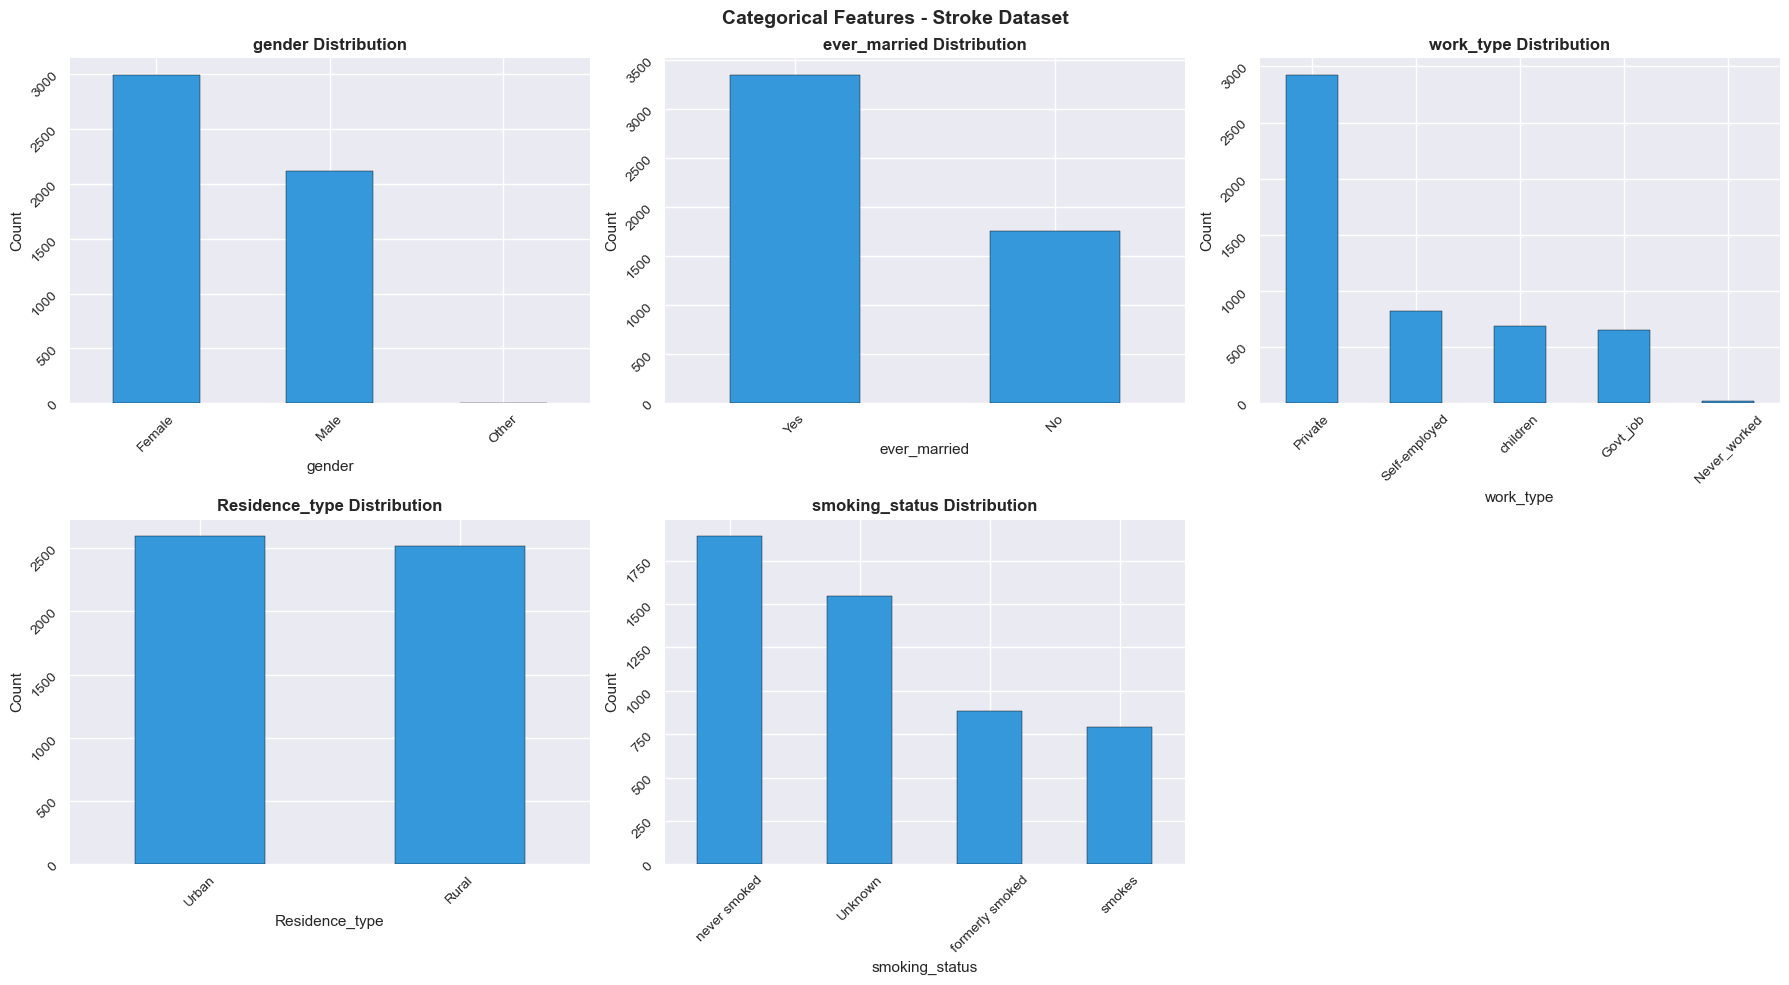

In [8]:
# Categorical Columns Analysis

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'id']
print("Categorical Columns:", cat_cols)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    print(f"\n{col}:")
    print(df[col].value_counts())

    df[col].value_counts().plot(kind='bar',
                                ax=axes[i],
                                color='#3498db',
                                edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features - Stroke Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

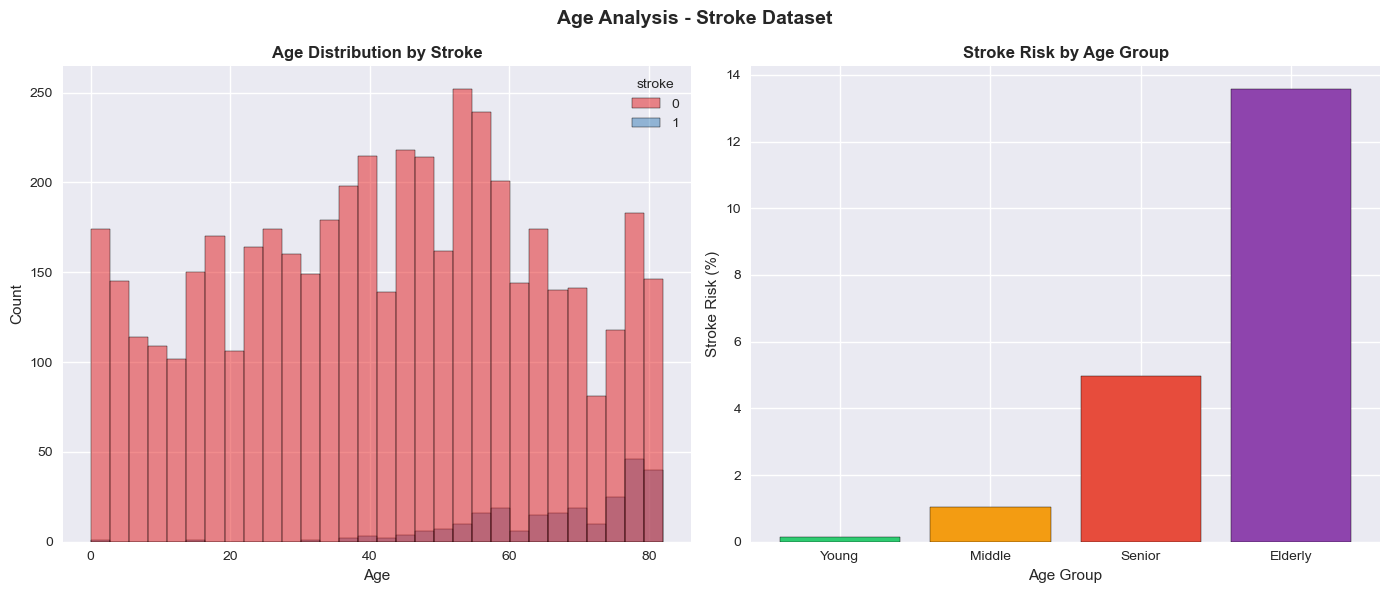

Elderly age group has highest stroke risk!


In [14]:
# Age vs Stroke Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df, x='age',
             hue='stroke', bins=30,
             palette='Set1', ax=axes[0])
axes[0].set_title('Age Distribution by Stroke',
                  fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

age_stroke = df.groupby(
    pd.cut(df['age'],
           bins=[0, 30, 45, 60, 100],
           labels=['Young', 'Middle', 'Senior', 'Elderly']),
    observed=True
)['stroke'].mean() * 100

axes[1].bar(age_stroke.index,
            age_stroke.values,
            color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
            edgecolor='black')
axes[1].set_title('Stroke Risk by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Stroke Risk (%)')

plt.suptitle('Age Analysis - Stroke Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Elderly age group has highest stroke risk!")

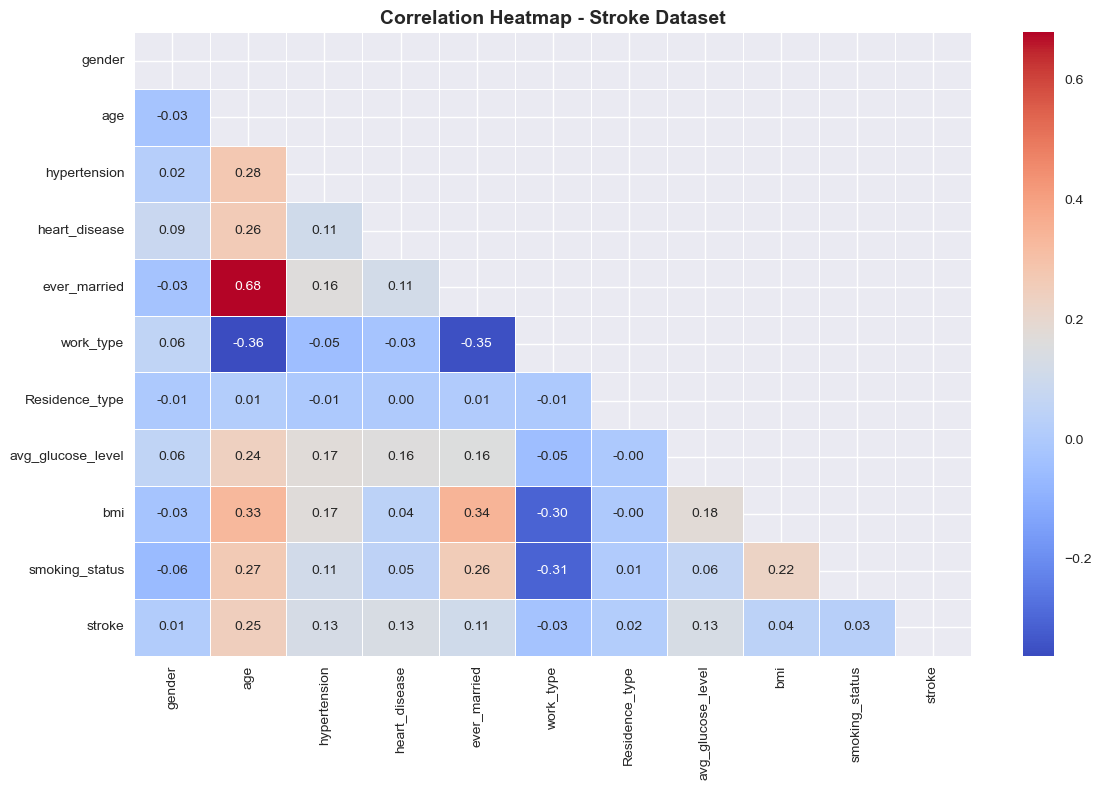

Top Correlations with Stroke:
stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.042374
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
work_type           -0.032316
Name: stroke, dtype: float64


In [10]:
# Correlation Heatmap

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_encoded = df.copy()
if 'id' in df_encoded.columns:
    df_encoded = df_encoded.drop('id', axis=1)

cat_cols = df_encoded.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(
        df_encoded[col].astype(str))

plt.figure(figsize=(12, 8))
correlation = df_encoded.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            mask=mask)

plt.title('Correlation Heatmap - Stroke Dataset',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top Correlations with Stroke:")
print(correlation['stroke'].sort_values(ascending=False))

In [11]:
# EDA Summary Report

print("=" * 60)
print("   STROKE EDA - SUMMARY REPORT")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Patients: {len(df)}")
print(f"Stroke Cases: {(df['stroke']==1).sum()}")
print(f"No Stroke: {(df['stroke']==0).sum()}")

print("\nKEY FINDINGS:")
print("-" * 40)
print("1. Dataset highly imbalanced (95% No, 5% Yes)")
print("2. Age is strongest predictor of stroke")
print("3. Hypertension increases stroke risk")
print("4. Heart disease increases stroke risk")
print("5. High glucose level related to stroke")
print("6. BMI has some missing values")

print("\nNEXT STEPS:")
print("-" * 40)
print("1. Data Cleaning")
print("2. Handle Imbalanced Data (SMOTE)")
print("3. Model Training")

print("\nStroke EDA Complete!")
print("=" * 60)

   STROKE EDA - SUMMARY REPORT

Dataset Shape: (5110, 12)
Total Patients: 5110
Stroke Cases: 249
No Stroke: 4861

KEY FINDINGS:
----------------------------------------
1. Dataset highly imbalanced (95% No, 5% Yes)
2. Age is strongest predictor of stroke
3. Hypertension increases stroke risk
4. Heart disease increases stroke risk
5. High glucose level related to stroke
6. BMI has some missing values

NEXT STEPS:
----------------------------------------
1. Data Cleaning
2. Handle Imbalanced Data (SMOTE)
3. Model Training

Stroke EDA Complete!
